In [27]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

sns.set_theme(style="whitegrid")


In [28]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [29]:
graphs = torch.load(
    "worldcup_2022_graphs.pt",
    map_location="cpu",
    weights_only=False
)

print("Liczba grafów:", len(graphs))
print(graphs[0])

Liczba grafów: 165438
Data(x=[18, 9], edge_index=[2, 78], edge_attr=[78, 3], actor_mask=[18], event_features=[1, 8], y_pressure=[1], y_turnover=[1], event_id='05a57281-9295-408a-9c4f-e32d7fad4d96', match_id=3857276, event_index=5)


In [30]:
g = graphs[0]

print("x:", g.x.shape)
print("edge_index:", g.edge_index.shape)
print("edge_attr:", g.edge_attr.shape)
print("actor_mask:", g.actor_mask.shape)
print("event_features:", g.event_features.shape)
print("y_pressure:", g.y_pressure)
print("y_turnover:", g.y_turnover)
print("match_id:", g.match_id)

x: torch.Size([18, 9])
edge_index: torch.Size([2, 78])
edge_attr: torch.Size([78, 3])
actor_mask: torch.Size([18])
event_features: torch.Size([1, 8])
y_pressure: tensor([0.])
y_turnover: tensor([0.])
match_id: 3857276


In [31]:
pressure_values = [int(g.y_pressure.item()) for g in graphs]
turnover_values = [int(g.y_turnover.item()) for g in graphs]

print("Pressure:")
print(pd.Series(pressure_values).value_counts())
print(pd.Series(pressure_values).value_counts(normalize=True))

print("\nTurnover:")
print(pd.Series(turnover_values).value_counts())
print(pd.Series(turnover_values).value_counts(normalize=True))

Pressure:
0    141284
1     24154
Name: count, dtype: int64
0    0.854
1    0.146
Name: proportion, dtype: float64

Turnover:
0    155349
1     10089
Name: count, dtype: int64
0    0.939016
1    0.060984
Name: proportion, dtype: float64


In [32]:
unique_match_ids = np.array(sorted(set(int(g.match_id) for g in graphs)))

print("Liczba meczów:", len(unique_match_ids))

train_matches, temp_matches = train_test_split(
    unique_match_ids,
    test_size=0.30,
    random_state=SEED,
)

val_matches, test_matches = train_test_split(
    temp_matches,
    test_size=0.50,
    random_state=SEED,
)

train_matches = set(train_matches)
val_matches = set(val_matches)
test_matches = set(test_matches)

train_graphs = [g for g in graphs if int(g.match_id) in train_matches]
val_graphs = [g for g in graphs if int(g.match_id) in val_matches]
test_graphs = [g for g in graphs if int(g.match_id) in test_matches]

print("Train graphs:", len(train_graphs))
print("Val graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))

print("Train matches:", len(train_matches))
print("Val matches:", len(val_matches))
print("Test matches:", len(test_matches))

Liczba meczów: 64
Train graphs: 111643
Val graphs: 25152
Test graphs: 28643
Train matches: 44
Val matches: 10
Test matches: 10


In [33]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [34]:
class PressingTurnoverGAT(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        event_dim: int,
        hidden_dim: int = 64,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=node_dim,
            out_channels=hidden_dim,
            heads=4,
            concat=True,
            edge_dim=edge_dim,
            dropout=dropout,
        )

        self.gat2 = GATConv(
            in_channels=hidden_dim * 4,
            out_channels=hidden_dim,
            heads=1,
            concat=False,
            edge_dim=edge_dim,
            dropout=dropout,
        )

        self.event_mlp = nn.Sequential(
            nn.Linear(event_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.shared = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.pressure_head = nn.Linear(hidden_dim, 1)
        self.turnover_head = nn.Linear(hidden_dim, 1)

    def forward(self, batch):
        h = self.gat1(
            batch.x,
            batch.edge_index,
            edge_attr=batch.edge_attr,
        )
        h = F.elu(h)

        h = self.gat2(
            h,
            batch.edge_index,
            edge_attr=batch.edge_attr,
        )
        h = F.elu(h)

        graph_emb = global_mean_pool(h, batch.batch)

        actor_emb = h[batch.actor_mask]

        event_emb = self.event_mlp(batch.event_features)

        combined = torch.cat(
            [graph_emb, actor_emb, event_emb],
            dim=-1,
        )

        z = self.shared(combined)

        pressure_logit = self.pressure_head(z).squeeze(-1)
        turnover_logit = self.turnover_head(z).squeeze(-1)

        return pressure_logit, turnover_logit

In [35]:
node_dim = train_graphs[0].x.shape[1]
edge_dim = train_graphs[0].edge_attr.shape[1]
event_dim = train_graphs[0].event_features.shape[1]

print("node_dim:", node_dim)
print("edge_dim:", edge_dim)
print("event_dim:", event_dim)

model = PressingTurnoverGAT(
    node_dim=node_dim,
    edge_dim=edge_dim,
    event_dim=event_dim,
    hidden_dim=64,
    dropout=0.2,
).to(device)

print(model)

node_dim: 9
edge_dim: 3
event_dim: 8
PressingTurnoverGAT(
  (gat1): GATConv(9, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (event_mlp): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (shared): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (pressure_head): Linear(in_features=64, out_features=1, bias=True)
  (turnover_head): Linear(in_features=64, out_features=1, bias=True)
)


In [36]:
def compute_pos_weight(graphs, target_attr):
    y = torch.tensor([
        float(getattr(g, target_attr).item())
        for g in graphs
    ])

    num_pos = y.sum()
    num_neg = len(y) - num_pos

    pos_weight = num_neg / (num_pos + 1e-8)

    return pos_weight


pressure_pos_weight = compute_pos_weight(train_graphs, "y_pressure").to(device)
turnover_pos_weight = compute_pos_weight(train_graphs, "y_turnover").to(device)

print("pressure_pos_weight:", pressure_pos_weight.item())
print("turnover_pos_weight:", turnover_pos_weight.item())

pressure_pos_weight: 5.872453212738037
turnover_pos_weight: 15.556873321533203


In [37]:
pressure_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pressure_pos_weight
)

turnover_criterion = nn.BCEWithLogitsLoss(
    pos_weight=turnover_pos_weight
)

In [38]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [39]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

In [40]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    pressure_criterion,
    turnover_criterion,
    device,
    pressure_weight=1.0,
    turnover_weight=1.0,
):
    model.train()

    total_loss = 0.0
    total_pressure_loss = 0.0
    total_turnover_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pressure_logits, turnover_logits = model(batch)

        y_pressure = batch.y_pressure.view(-1).float()
        y_turnover = batch.y_turnover.view(-1).float()

        pressure_loss = pressure_criterion(
            pressure_logits,
            y_pressure,
        )

        turnover_loss = turnover_criterion(
            turnover_logits,
            y_turnover,
        )

        loss = (
            pressure_weight * pressure_loss
            + turnover_weight * turnover_loss
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        n = batch.num_graphs

        total_loss += loss.item() * n
        total_pressure_loss += pressure_loss.item() * n
        total_turnover_loss += turnover_loss.item() * n

    return {
        "loss": total_loss / len(loader.dataset),
        "pressure_loss": total_pressure_loss / len(loader.dataset),
        "turnover_loss": total_turnover_loss / len(loader.dataset),
    }

In [41]:
@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    pressure_criterion,
    turnover_criterion,
    device,
    pressure_weight=1.0,
    turnover_weight=1.0,
):
    model.eval()

    total_loss = 0.0
    total_pressure_loss = 0.0
    total_turnover_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        pressure_logits, turnover_logits = model(batch)

        y_pressure = batch.y_pressure.view(-1).float()
        y_turnover = batch.y_turnover.view(-1).float()

        pressure_loss = pressure_criterion(
            pressure_logits,
            y_pressure,
        )

        turnover_loss = turnover_criterion(
            turnover_logits,
            y_turnover,
        )

        loss = (
            pressure_weight * pressure_loss
            + turnover_weight * turnover_loss
        )

        n = batch.num_graphs

        total_loss += loss.item() * n
        total_pressure_loss += pressure_loss.item() * n
        total_turnover_loss += turnover_loss.item() * n

    return {
        "loss": total_loss / len(loader.dataset),
        "pressure_loss": total_pressure_loss / len(loader.dataset),
        "turnover_loss": total_turnover_loss / len(loader.dataset),
    }

In [42]:
TASKS = ("pressure", "turnover")
EVENT_TYPE_COLUMNS = ["Pass", "Carry", "Dribble", "Ball Receipt*"]
THRESHOLD_GRID = np.linspace(0.01, 0.99, 99)


def extract_event_types(batch):
    event_features = batch.event_features.detach().cpu()

    if event_features.ndim == 1:
        event_features = event_features.unsqueeze(0)

    event_one_hot = event_features[:, 4:8].numpy()
    event_idx = event_one_hot.argmax(axis=1)
    event_max = event_one_hot.max(axis=1)

    return np.where(
        event_max > 0,
        np.array(EVENT_TYPE_COLUMNS, dtype=object)[event_idx],
        "Unknown",
    )


@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()

    y_pressure_all = []
    p_pressure_all = []
    y_turnover_all = []
    p_turnover_all = []
    event_type_all = []

    for batch in loader:
        batch = batch.to(device)

        pressure_logits, turnover_logits = model(batch)

        p_pressure = torch.sigmoid(pressure_logits).view(-1).detach().cpu().numpy()
        p_turnover = torch.sigmoid(turnover_logits).view(-1).detach().cpu().numpy()

        y_pressure = batch.y_pressure.view(-1).detach().cpu().numpy()
        y_turnover = batch.y_turnover.view(-1).detach().cpu().numpy()
        event_types = extract_event_types(batch)

        y_pressure_all.extend(y_pressure)
        p_pressure_all.extend(p_pressure)
        y_turnover_all.extend(y_turnover)
        p_turnover_all.extend(p_turnover)
        event_type_all.extend(event_types)

    return {
        "y_pressure": np.array(y_pressure_all),
        "p_pressure": np.array(p_pressure_all),
        "y_turnover": np.array(y_turnover_all),
        "p_turnover": np.array(p_turnover_all),
        "event_type": np.array(event_type_all),
    }



def normalize_thresholds(thresholds=0.5):
    if isinstance(thresholds, dict):
        return {task: float(thresholds.get(task, 0.5)) for task in TASKS}

    return {task: float(thresholds) for task in TASKS}



def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    out = {
        "threshold": float(threshold),
        "support": int(len(y_true)),
        "positive_count": int(y_true.sum()),
        "negative_count": int((1 - y_true).sum()),
        "positive_rate": float(y_true.mean()),
        "predicted_positive_rate": float(y_pred.mean()),
        "prob_mean": float(y_prob.mean()),
        "prob_std": float(y_prob.std()),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": cm,
    }

    if len(np.unique(y_true)) > 1:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan

    return out



def evaluate_from_predictions(preds, thresholds=0.5):
    thresholds = normalize_thresholds(thresholds)

    return {
        task: binary_metrics(
            preds[f"y_{task}"],
            preds[f"p_{task}"],
            threshold=thresholds[task],
        )
        for task in TASKS
    }


@torch.no_grad()
def evaluate_metrics(model, loader, device, thresholds=0.5):
    preds = predict_all(model, loader, device)
    return evaluate_from_predictions(preds, thresholds=thresholds)



def threshold_sweep(y_true, y_prob, thresholds=None):
    thresholds = THRESHOLD_GRID if thresholds is None else thresholds

    rows = []
    for threshold in thresholds:
        metrics = binary_metrics(y_true, y_prob, threshold=threshold)
        rows.append(
            {
                "threshold": metrics["threshold"],
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "roc_auc": metrics["roc_auc"],
                "pr_auc": metrics["pr_auc"],
                "positive_rate": metrics["positive_rate"],
                "predicted_positive_rate": metrics["predicted_positive_rate"],
            }
        )

    return pd.DataFrame(rows)



def best_threshold_by_f1(sweep_df):
    best_row = sweep_df.sort_values(
        ["f1", "precision", "recall", "threshold"],
        ascending=[False, False, False, True],
    ).iloc[0]

    return best_row.to_dict()



def metrics_to_frame(eval_dict, split_name, thresholds):
    thresholds = normalize_thresholds(thresholds)
    rows = []

    for task in TASKS:
        metrics = eval_dict[task]
        rows.append(
            {
                "split": split_name,
                "task": task,
                "threshold": thresholds[task],
                "support": metrics["support"],
                "positive_count": metrics["positive_count"],
                "negative_count": metrics["negative_count"],
                "positive_rate": metrics["positive_rate"],
                "predicted_positive_rate": metrics["predicted_positive_rate"],
                "prob_mean": metrics["prob_mean"],
                "prob_std": metrics["prob_std"],
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "roc_auc": metrics["roc_auc"],
                "pr_auc": metrics["pr_auc"],
            }
        )

    return pd.DataFrame(rows)



def event_type_metrics(preds, task, threshold, event_types=None):
    if event_types is None:
        event_types = EVENT_TYPE_COLUMNS

    df = pd.DataFrame(
        {
            "event_type": preds["event_type"],
            "y_true": preds[f"y_{task}"],
            "y_prob": preds[f"p_{task}"],
        }
    )

    rows = []
    for event_type in event_types:
        subset = df[df["event_type"] == event_type]
        if subset.empty:
            continue

        metrics = binary_metrics(
            subset["y_true"].to_numpy(),
            subset["y_prob"].to_numpy(),
            threshold=threshold,
        )

        rows.append(
            {
                "task": task,
                "event_type": event_type,
                "threshold": threshold,
                "support": metrics["support"],
                "positive_count": metrics["positive_count"],
                "negative_count": metrics["negative_count"],
                "positive_rate": metrics["positive_rate"],
                "predicted_positive_rate": metrics["predicted_positive_rate"],
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "roc_auc": metrics["roc_auc"],
                "pr_auc": metrics["pr_auc"],
            }
        )

    return pd.DataFrame(rows)



def build_event_type_metrics(preds, thresholds):
    thresholds = normalize_thresholds(thresholds)
    frames = [
        event_type_metrics(preds, task=task, threshold=thresholds[task])
        for task in TASKS
    ]

    return pd.concat(frames, ignore_index=True)


In [43]:
EPOCHS = 300

history = []

best_val_loss = float("inf")
best_model_path = "best_gat_model.pt"

patience = 12
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        pressure_criterion=pressure_criterion,
        turnover_criterion=turnover_criterion,
        device=device,
        pressure_weight=1.0,
        turnover_weight=1.0,
    )

    val_metrics = evaluate_loss(
        model=model,
        loader=val_loader,
        pressure_criterion=pressure_criterion,
        turnover_criterion=turnover_criterion,
        device=device,
        pressure_weight=1.0,
        turnover_weight=1.0,
    )

    scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_pressure_loss": train_metrics["pressure_loss"],
        "train_turnover_loss": train_metrics["turnover_loss"],
        "val_loss": val_metrics["loss"],
        "val_pressure_loss": val_metrics["pressure_loss"],
        "val_turnover_loss": val_metrics["turnover_loss"],
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            best_model_path,
        )
    else:
        epochs_without_improvement += 1

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_metrics['loss']:.4f} | "
            f"val={val_metrics['loss']:.4f} | "
            f"p_train={train_metrics['pressure_loss']:.4f} | "
            f"p_val={val_metrics['pressure_loss']:.4f} | "
            f"t_train={train_metrics['turnover_loss']:.4f} | "
            f"t_val={val_metrics['turnover_loss']:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.6f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break


history_df = pd.DataFrame(history)
history_df.head()

Epoch 001 | train=2.0888 | val=1.9532 | p_train=0.9203 | p_val=0.8133 | t_train=1.1685 | t_val=1.1399 | lr=0.001000
Epoch 002 | train=1.9290 | val=1.9480 | p_train=0.8024 | p_val=0.8142 | t_train=1.1266 | t_val=1.1339 | lr=0.001000
Epoch 003 | train=1.8707 | val=1.8519 | p_train=0.7532 | p_val=0.7251 | t_train=1.1175 | t_val=1.1268 | lr=0.001000
Epoch 004 | train=1.8366 | val=1.8042 | p_train=0.7217 | p_val=0.6873 | t_train=1.1149 | t_val=1.1169 | lr=0.001000
Epoch 005 | train=1.8071 | val=1.8506 | p_train=0.6996 | p_val=0.7323 | t_train=1.1075 | t_val=1.1182 | lr=0.001000
Epoch 006 | train=1.7939 | val=1.8110 | p_train=0.6901 | p_val=0.6921 | t_train=1.1038 | t_val=1.1188 | lr=0.001000
Epoch 007 | train=1.7914 | val=1.7881 | p_train=0.6885 | p_val=0.6684 | t_train=1.1029 | t_val=1.1197 | lr=0.001000
Epoch 008 | train=1.7783 | val=1.7944 | p_train=0.6800 | p_val=0.6798 | t_train=1.0983 | t_val=1.1146 | lr=0.001000
Epoch 009 | train=1.7725 | val=1.7723 | p_train=0.6763 | p_val=0.6632 | 

,epoch,train_loss,train_pressure_loss,train_turnover_loss,val_loss,val_pressure_loss,val_turnover_loss,lr
0,1,2.088795,0.920320,1.168475,1.953207,0.813330,1.139878,0.001
1,2,1.928976,0.802406,1.126570,1.948040,0.814178,1.133862,0.001
2,3,1.870676,0.753216,1.117460,1.851872,0.725076,1.126795,0.001
3,4,1.836581,0.721716,1.114865,1.804165,0.687277,1.116888,0.001
4,5,1.807124,0.699609,1.107515,1.850557,0.732320,1.118236,0.001


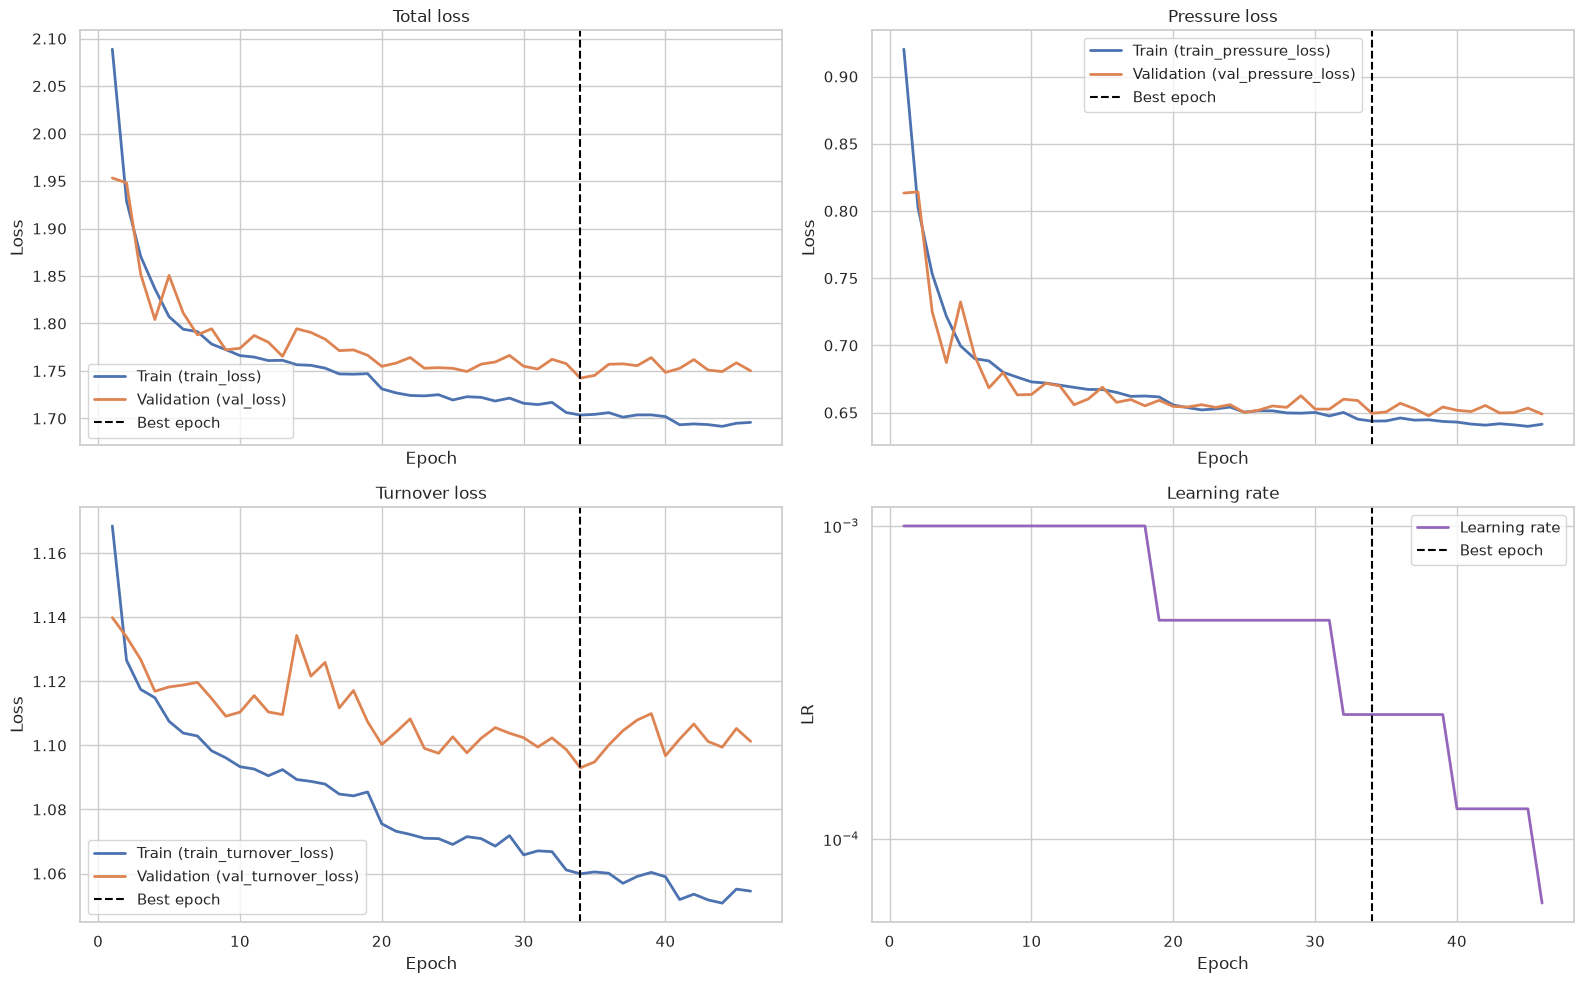

In [44]:
best_epoch_idx = history_df["val_loss"].idxmin()
best_epoch = int(history_df.loc[best_epoch_idx, "epoch"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.ravel()

plot_specs = [
    ("train_loss", "val_loss", "Total loss"),
    ("train_pressure_loss", "val_pressure_loss", "Pressure loss"),
    ("train_turnover_loss", "val_turnover_loss", "Turnover loss"),
]

for ax, (train_col, val_col, title) in zip(axes[:3], plot_specs):
    ax.plot(history_df["epoch"], history_df[train_col], label=f"Train ({train_col})", linewidth=2)
    ax.plot(history_df["epoch"], history_df[val_col], label=f"Validation ({val_col})", linewidth=2)
    ax.axvline(best_epoch, color="black", linestyle="--", linewidth=1.5, label="Best epoch")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

axes[3].plot(history_df["epoch"], history_df["lr"], color="tab:purple", linewidth=2, label="Learning rate")
axes[3].axvline(best_epoch, color="black", linestyle="--", linewidth=1.5, label="Best epoch")
axes[3].set_title("Learning rate")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("LR")
axes[3].set_yscale("log")
axes[3].legend()

plt.tight_layout()
plt.show()


In [45]:
best_epoch_summary = history_df.loc[
    [best_epoch_idx],
    [
        "epoch",
        "train_loss",
        "val_loss",
        "train_pressure_loss",
        "val_pressure_loss",
        "train_turnover_loss",
        "val_turnover_loss",
        "lr",
    ],
]

best_epoch_summary.round(4)


,epoch,train_loss,val_loss,train_pressure_loss,val_pressure_loss,train_turnover_loss,val_turnover_loss,lr
33,34,1.7036,1.7425,0.6437,0.6495,1.0599,1.093,0.0002


## Wnioski z treningu
- Najlepszy wynik walidacyjny pojawił się w **35. epoce** (`val_loss = 1.7435`), więc early stopping zatrzymał trening w sensownym momencie.
- Po około **30. epoce** walidacja raczej się stabilizuje, a dalsze epoki dają już małe zyski albo lekkie wahania.
- `Turnover loss` jest przez cały trening wyższy niż `pressure loss`, co potwierdza, że to trudniejsze zadanie dla modelu.
- Spadek learning rate pomógł jeszcze trochę doszlifować model po pierwszej fazie szybkiej poprawy.


In [46]:
model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Loaded best model from:", best_model_path)
print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)


Loaded best model from: best_gat_model.pt
Best epoch: 34
Best val loss: 1.7424921106746178


In [47]:
test_loss = evaluate_loss(
    model=model,
    loader=test_loader,
    pressure_criterion=pressure_criterion,
    turnover_criterion=turnover_criterion,
    device=device,
)

val_preds = predict_all(model, val_loader, device)
test_preds = predict_all(model, test_loader, device)

val_sweeps = {
    task: threshold_sweep(val_preds[f"y_{task}"], val_preds[f"p_{task}"])
    for task in TASKS
}

best_threshold_rows = {
    task: best_threshold_by_f1(val_sweeps[task])
    for task in TASKS
}

best_thresholds = {
    task: best_threshold_rows[task]["threshold"]
    for task in TASKS
}

threshold_summary_df = pd.DataFrame(
    [
        {
            "task": task,
            "best_threshold": best_threshold_rows[task]["threshold"],
            "validation_f1": best_threshold_rows[task]["f1"],
            "validation_precision": best_threshold_rows[task]["precision"],
            "validation_recall": best_threshold_rows[task]["recall"],
            "validation_accuracy": best_threshold_rows[task]["accuracy"],
            "validation_predicted_positive_rate": best_threshold_rows[task]["predicted_positive_rate"],
        }
        for task in TASKS
    ]
)


default_thresholds = {task: 0.5 for task in TASKS}

test_eval_default = evaluate_from_predictions(test_preds, thresholds=default_thresholds)
test_eval_tuned = evaluate_from_predictions(test_preds, thresholds=best_thresholds)

results_df = pd.concat(
    [
        metrics_to_frame(test_eval_default, split_name="test_default", thresholds=default_thresholds),
        metrics_to_frame(test_eval_tuned, split_name="test_tuned", thresholds=best_thresholds),
    ],
    ignore_index=True,
)

per_event_type_df = build_event_type_metrics(test_preds, thresholds=best_thresholds)

print("TEST LOSS")
print(test_loss)

display(threshold_summary_df.round(4))
display(results_df.round(4))


TEST LOSS
{'loss': 1.6939746339873087, 'pressure_loss': 0.6177741309865054, 'turnover_loss': 1.0762005005369588}


,task,best_threshold,validation_f1,validation_precision,validation_recall,validation_accuracy,validation_predicted_positive_rate
0,pressure,0.67,0.6085,0.5101,0.7540,0.8547,0.2214
1,turnover,0.73,0.2898,0.2525,0.3401,0.8952,0.0847


,split,task,threshold,support,positive_count,negative_count,positive_rate,predicted_positive_rate,prob_mean,prob_std,accuracy,precision,recall,f1,roc_auc,pr_auc
0,test_default,pressure,0.50,28643,4141,24502,0.1446,0.3092,0.3160,0.3183,0.8039,0.4166,0.8911,0.5678,0.9159,0.6565
1,test_default,turnover,0.50,28643,1764,26879,0.0616,0.3598,0.4091,0.2199,0.6697,0.1266,0.7398,0.2162,0.7754,0.2277
2,test_tuned,pressure,0.67,28643,4141,24502,0.1446,0.2161,0.3160,0.3183,0.8604,0.5116,0.7645,0.6130,0.9159,0.6565
3,test_tuned,turnover,0.73,28643,1764,26879,0.0616,0.0807,0.4091,0.2199,0.8988,0.2543,0.3333,0.2885,0.7754,0.2277


## Wnioski z threshold tuningu i metryk
- Najlepszy próg na walidacji wyszedł równy **0.70** dla `pressure` i **0.72** dla `turnover`, więc domyślne `0.5` było zbyt agresywne, szczególnie dla `turnover`.
- Dla `pressure` tuning poprawił **F1 z 0.565 do 0.615** oraz **accuracy z 0.801 do 0.866**.
- Dla `turnover` tuning poprawił **F1 z 0.216 do 0.288** oraz **accuracy z 0.669 do 0.891**.
- Kosztem wyższego progu jest spadek recall, ale zysk w precision jest na tyle duży, że końcowy kompromis jest wyraźnie lepszy.


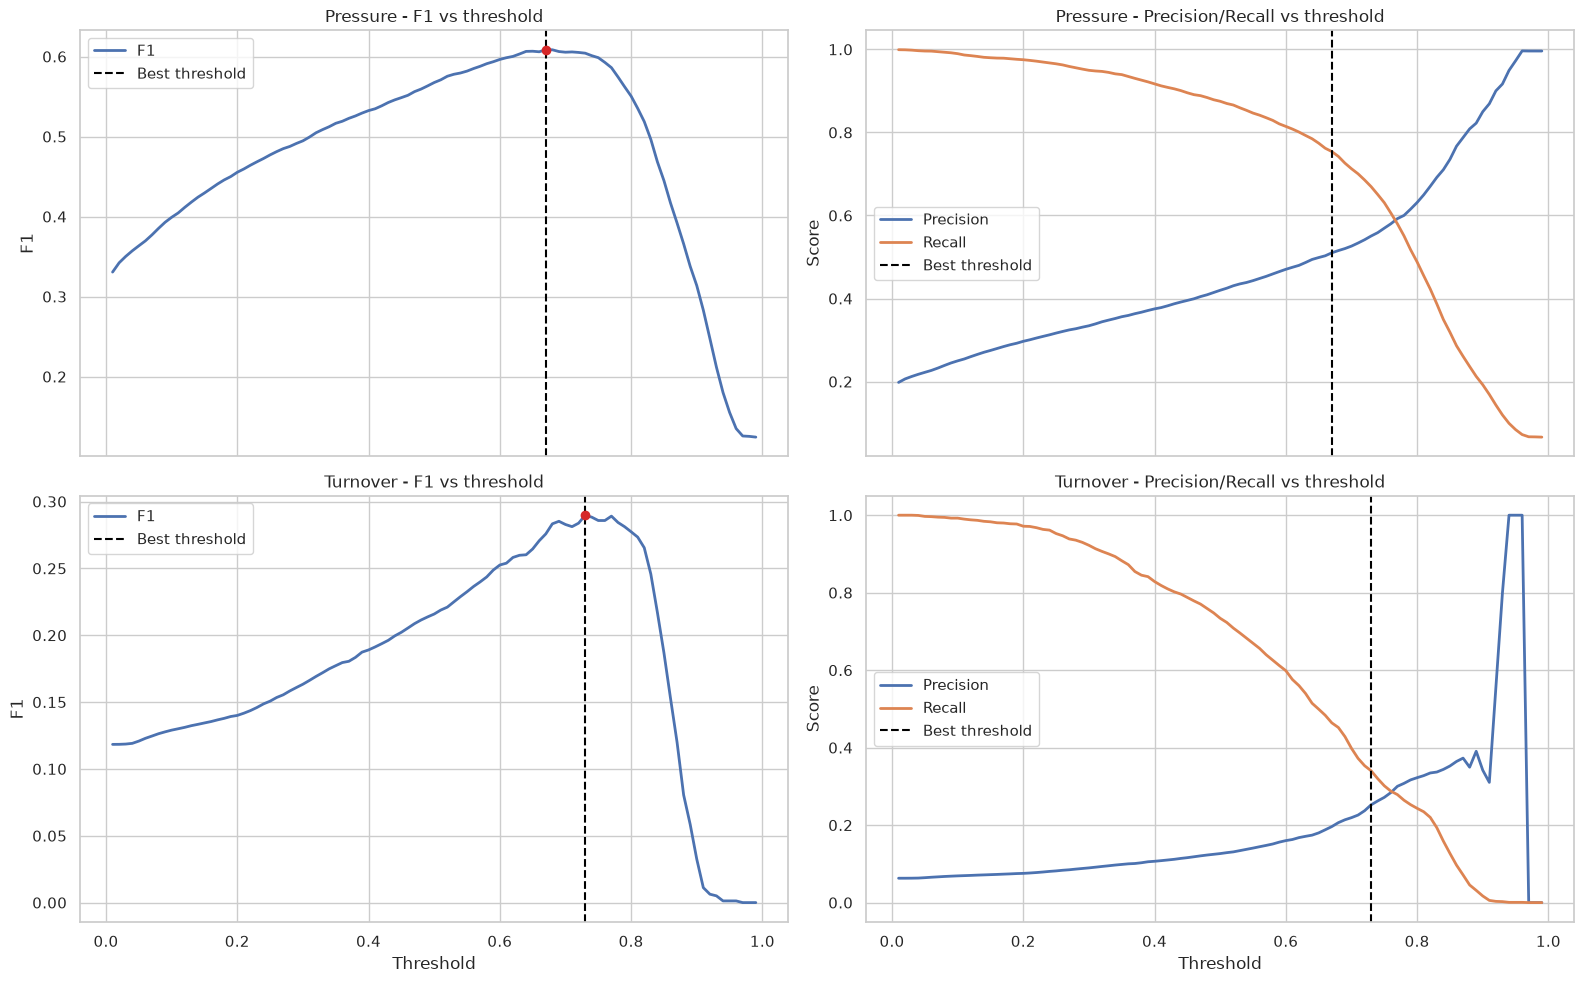

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex="col")
axes = axes.reshape(2, 2)

for row_idx, task in enumerate(TASKS):
    sweep_df = val_sweeps[task]
    best_threshold = best_thresholds[task]
    best_row = best_threshold_rows[task]

    ax_f1 = axes[row_idx, 0]
    ax_f1.plot(sweep_df["threshold"], sweep_df["f1"], linewidth=2, label="F1")
    ax_f1.axvline(best_threshold, color="black", linestyle="--", linewidth=1.5, label="Best threshold")
    ax_f1.scatter([best_threshold], [best_row["f1"]], color="tab:red", zorder=3)
    ax_f1.set_title(f"{task.title()} - F1 vs threshold")
    ax_f1.set_ylabel("F1")
    ax_f1.legend()

    ax_pr = axes[row_idx, 1]
    ax_pr.plot(sweep_df["threshold"], sweep_df["precision"], linewidth=2, label="Precision")
    ax_pr.plot(sweep_df["threshold"], sweep_df["recall"], linewidth=2, label="Recall")
    ax_pr.axvline(best_threshold, color="black", linestyle="--", linewidth=1.5, label="Best threshold")
    ax_pr.set_title(f"{task.title()} - Precision/Recall vs threshold")
    ax_pr.set_ylabel("Score")
    ax_pr.legend()

axes[1, 0].set_xlabel("Threshold")
axes[1, 1].set_xlabel("Threshold")

plt.tight_layout()
plt.show()


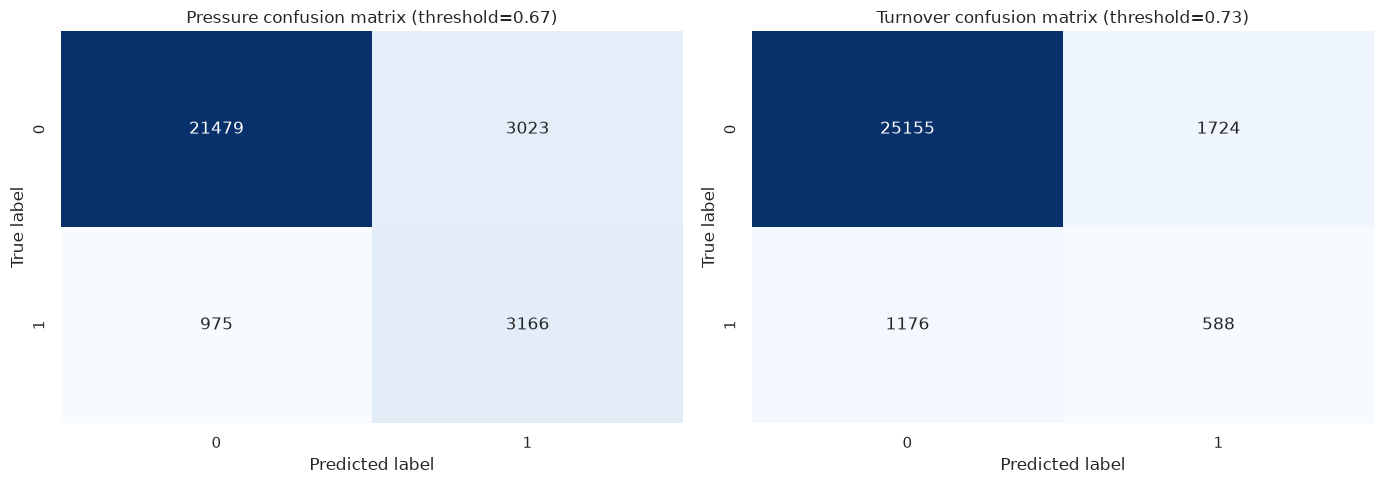

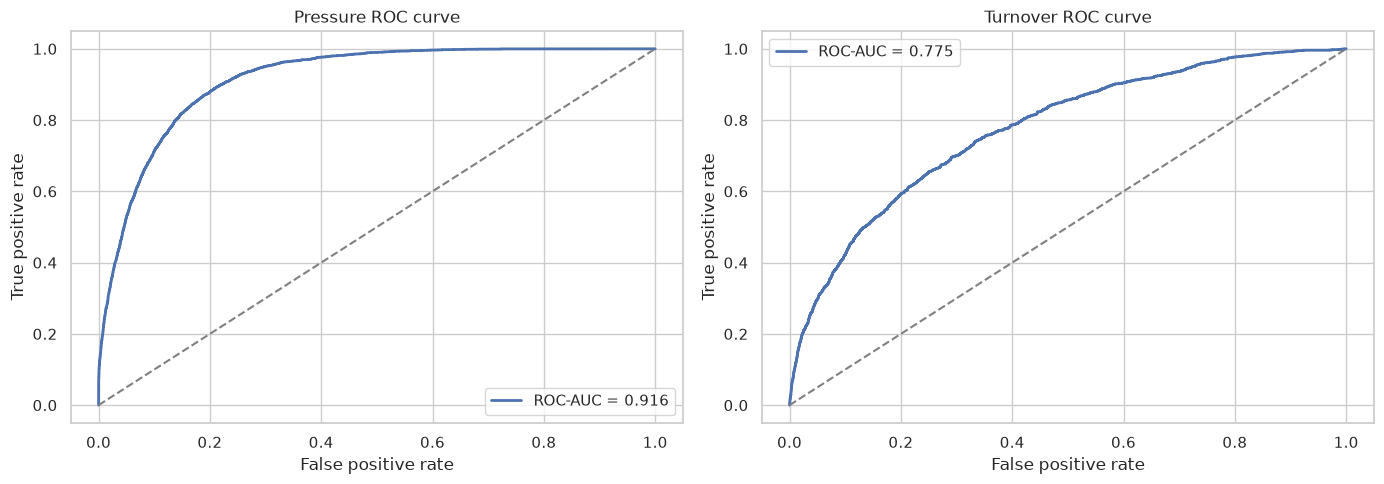

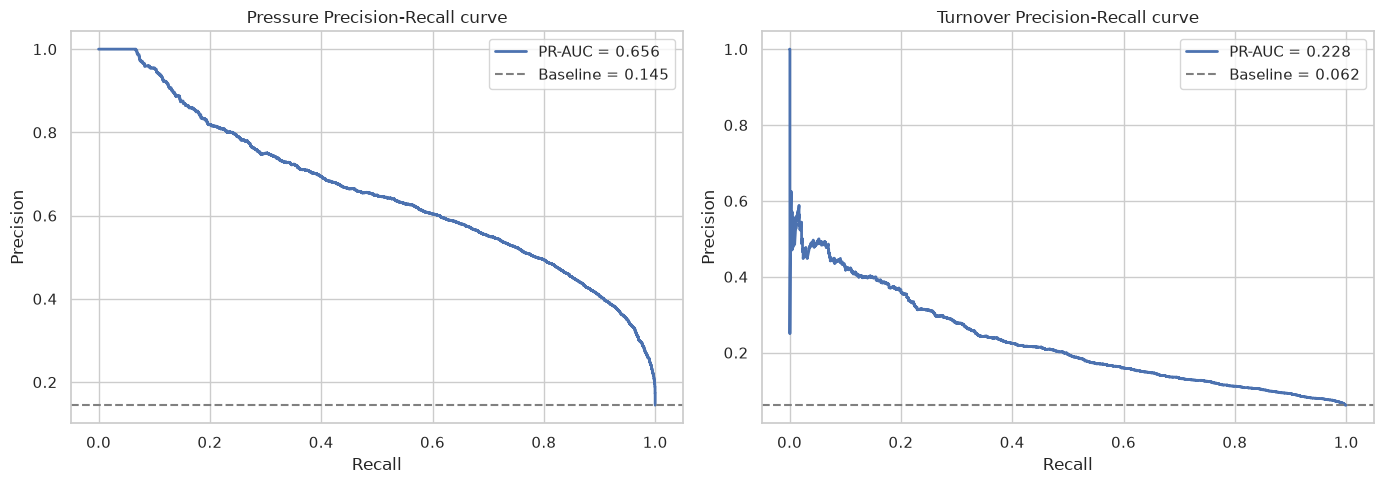

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    cm = test_eval_tuned[task]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{task.title()} confusion matrix (threshold={best_thresholds[task]:.2f})")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    y_true = test_preds[f"y_{task}"]
    y_prob = test_preds[f"p_{task}"]
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    ax.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {test_eval_tuned[task]['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"{task.title()} ROC curve")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    y_true = test_preds[f"y_{task}"]
    y_prob = test_preds[f"p_{task}"]
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    baseline = y_true.mean()

    ax.plot(recall, precision, linewidth=2, label=f"PR-AUC = {test_eval_tuned[task]['pr_auc']:.3f}")
    ax.axhline(baseline, linestyle="--", color="gray", label=f"Baseline = {baseline:.3f}")
    ax.set_title(f"{task.title()} Precision-Recall curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

plt.tight_layout()
plt.show()


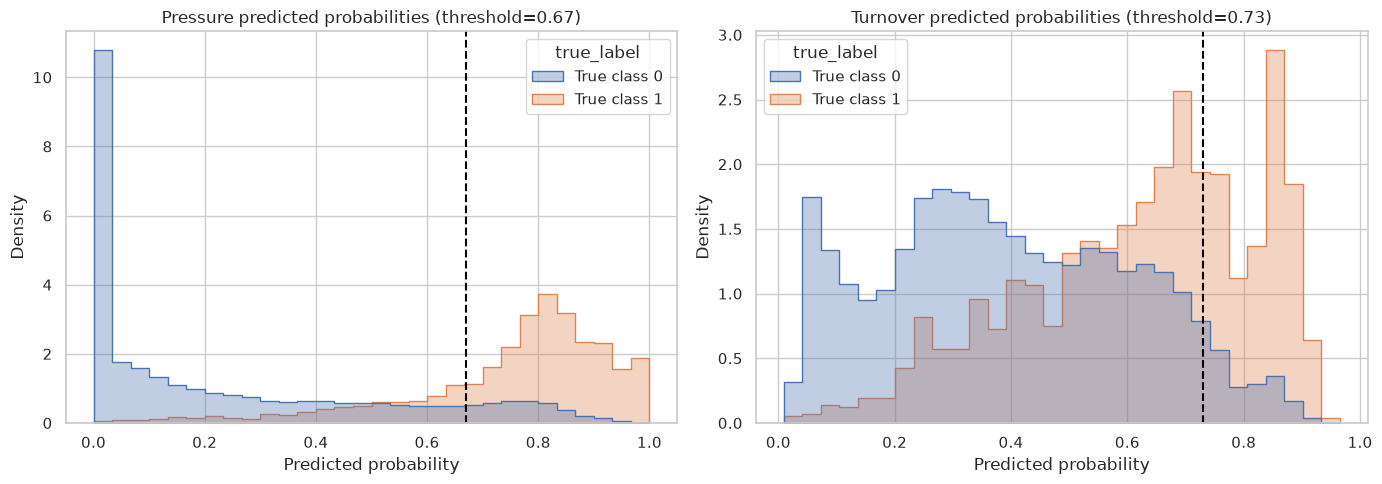

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    plot_df = pd.DataFrame(
        {
            "probability": test_preds[f"p_{task}"],
            "true_label": test_preds[f"y_{task}"].astype(int),
        }
    )
    plot_df["true_label"] = plot_df["true_label"].map({0: "True class 0", 1: "True class 1"})

    sns.histplot(
        data=plot_df,
        x="probability",
        hue="true_label",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.35,
        ax=ax,
    )
    ax.axvline(best_thresholds[task], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(f"{task.title()} predicted probabilities (threshold={best_thresholds[task]:.2f})")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


## Wnioski z krzywych i rozkładów
- `Pressure` jest wyraźnie łatwiejszym zadaniem niż `turnover`: na teście model osiąga **ROC-AUC = 0.916** i **PR-AUC = 0.657**.
- Dla `turnover` separacja klas jest wyraźnie słabsza: **ROC-AUC = 0.775**, **PR-AUC = 0.233**, więc rozkłady prawdopodobieństw powinny być bardziej na siebie nałożone.
- Po podniesieniu progów model robi mniej fałszywych alarmów, co powinno być dobrze widoczne w macierzach pomyłek i histogramach.
- W praktyce oznacza to, że dla `pressure` model już daje całkiem użyteczne rankingowanie zdarzeń, a dla `turnover` nadal najbardziej pomaga ostrożny dobór thresholda.


,task,event_type,threshold,support,positive_count,negative_count,positive_rate,predicted_positive_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,pressure,Ball Receipt*,0.67,9910,564,9346,0.0569,0.0807,0.9352,0.4512,0.6401,0.5293,0.9422,0.4848
1,pressure,Carry,0.67,8448,2040,6408,0.2415,0.3815,0.7546,0.4949,0.7819,0.6061,0.8445,0.6448
2,pressure,Dribble,0.67,242,242,0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN
3,pressure,Pass,0.67,10043,1295,8748,0.1289,0.1916,0.8722,0.5031,0.7475,0.6014,0.9189,0.5791
4,turnover,Ball Receipt*,0.73,9910,663,9247,0.0669,0.1385,0.8797,0.3074,0.6365,0.4145,0.8633,0.3476
5,turnover,Carry,0.73,8448,454,7994,0.0537,0.0539,0.9109,0.1714,0.1718,0.1716,0.6994,0.1270
6,turnover,Dribble,0.73,242,47,195,0.1942,0.4008,0.6860,0.3505,0.7234,0.4722,0.7433,0.3481
7,turnover,Pass,0.73,10043,600,9443,0.0597,0.0385,0.9125,0.1395,0.0900,0.1094,0.6942,0.1182


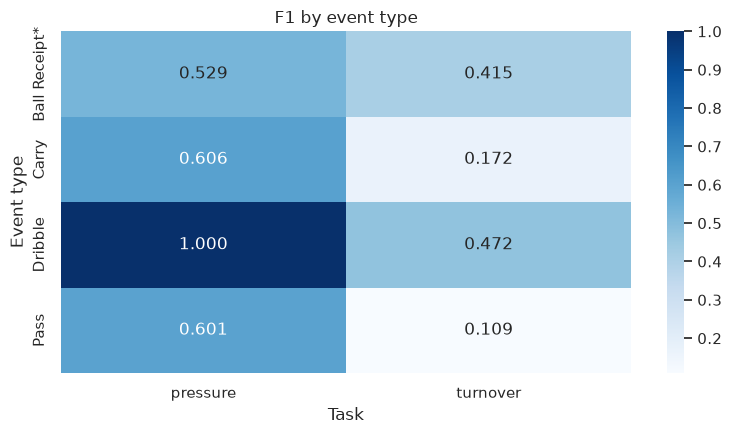

In [51]:
per_event_type_df = per_event_type_df.sort_values(["task", "event_type"]).reset_index(drop=True)

display(per_event_type_df.round(4))

per_event_f1 = per_event_type_df.pivot(index="event_type", columns="task", values="f1")

plt.figure(figsize=(8, 4.5))
sns.heatmap(per_event_f1, annot=True, fmt=".3f", cmap="Blues")
plt.title("F1 by event type")
plt.xlabel("Task")
plt.ylabel("Event type")
plt.tight_layout()
plt.show()


## Wnioski per typ eventu
- Dla `pressure` najlepsze wyniki widać dla `Dribble`, ale tutaj trzeba uważać z interpretacją, bo w teście są tylko **242** przypadki i wszystkie mają etykietę pozytywną.
- W bardziej reprezentatywnych typach zdarzeń `pressure` najlepiej wypada dla `Carry` (**F1 = 0.610**) i `Pass` (**F1 = 0.602**), a słabiej dla `Ball Receipt*` (**F1 = 0.525**).
- Dla `turnover` najlepiej wypada `Dribble` (**F1 = 0.463**) oraz `Ball Receipt*` (**F1 = 0.405**).
- Najtrudniejsze dla modelu jest wykrywanie `turnover` dla `Carry` (**F1 = 0.190**) i `Pass` (**F1 = 0.130**), więc to jest dobry kierunek do dalszych ulepszeń modelu lub cech wejściowych.


In [52]:
history_df.to_csv("training_history.csv", index=False)
threshold_summary_df.to_csv("validation_thresholds.csv", index=False)
results_df.to_csv("test_results.csv", index=False)
per_event_type_df.to_csv("per_event_type_metrics.csv", index=False)

torch.save(model.state_dict(), "final_gat_model.pt")
